## CLUSTERING PONDERADO SOBRE DATASET ELECTORAL
Aplica los tres algoritmos ponderados (W-KMedoids, W-Hierarchical, W-DBSCAN) sobre el dataset electoral preprocesado usando el esquema de ponderación del proyecto. Sigue el mismo proceso de búsqueda de parámetros que el notebook de algoritmos tradicionales.

### INICIALIZACIÓN

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

from src.clustering.weighted import WKMedoids, WeightedHierarchicalClustering, WDBSCAN
from src.weighting.weight_manager import WeightManager
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH, RESULTS_PATH
from src.utils.params_search import analyze_dbscan_params, build_dbscan_configs

sns.set_style('whitegrid')
np.random.seed(42)

print('='*70)
print('CLUSTERING PONDERADO — DATASET ELECTORAL LAPOP BOLIVIA 2023')
print('='*70)

# Cargar dataset preprocesado
df = pd.read_csv(PROCESSED_DATA_PATH)
print(f'\n✓ Dataset cargado:')
print(f'  Dimensiones: {df.shape[0]} registros × {df.shape[1]} variables')
print(f'  Missings: {df.isnull().sum().sum()}')

# Cargar esquema de ponderación real
wm = WeightManager()
weights_dict = wm.get_weights()
print(f'\n✓ WeightManager cargado: {len(weights_dict)} características')
print(f'  Ruta: {wm.weights_path_}')
print(f'  Rango de pesos: [{min(weights_dict.values()):.2f}, {max(weights_dict.values()):.2f}]')
print('='*70)

CLUSTERING PONDERADO — DATASET ELECTORAL LAPOP BOLIVIA 2023

✓ Dataset cargado:
  Dimensiones: 1706 registros × 28 variables
  Missings: 0
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.

✓ WeightManager cargado: 42 características
  Ruta: c:\electocluster\src\weighting\schemas\feature_weights.json
  Rango de pesos: [0.50, 1.00]


### W-KMEDOIDS

In [2]:
print('\n--- BÚSQUEDA DE CONFIGURACIÓN - W-KMEDOIDS ---\n')

k_range = range(2, 25)  # Regla de Sturges: k_max = 1 + log₂(1706) ≈ 11
resultados_k = []

for k in k_range:
    wkm_temp = WKMedoids(n_clusters=k, random_state=42, weight_manager=wm)
    wkm_temp.fit(df)
    metrics_temp = calculate_metrics(df, wkm_temp.labels_)
    resultados_k.append({
        'k': k,
        'inercia': wkm_temp.inertia_,
        'silhouette': metrics_temp['silhouette'],
        'davies_bouldin': metrics_temp['davies_bouldin']
    })
    print(f'  k={k}: Inercia={wkm_temp.inertia_:.2f} | '
          f'DB={metrics_temp["davies_bouldin"]:.4f}')

# Criterio compuesto: 60% Silhouette + 40% Davies-Bouldin
sil_vals = np.array([r['silhouette'] for r in resultados_k])
db_vals  = np.array([r['davies_bouldin'] for r in resultados_k])

sil_norm = (sil_vals - sil_vals.min()) / (sil_vals.max() - sil_vals.min())
db_norm  = 1 - (db_vals - db_vals.min()) / (db_vals.max() - db_vals.min())

score_combinado = 0.6 * sil_norm + 0.4 * db_norm

mejor_idx = np.argmax(score_combinado)
k_optimo  = resultados_k[mejor_idx]['k']

print(f'\n  k óptimo por Silhouette:       k={resultados_k[np.argmax(sil_vals)]["k"]}')
print(f'  k óptimo por Davies-Bouldin:   k={resultados_k[np.argmin(db_vals)]["k"]}')
print(f'  k óptimo por criterio compuesto (60% Sil + 40% DB): k={k_optimo}')


--- BÚSQUEDA DE CONFIGURACIÓN - W-KMEDOIDS ---

Entrenando Weighted K-Medoids con 2 clusters...
✓ WK-Medoids entrenado: 2 clusters identificados
  Inercia: 2473.9323
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.0895
  ✓ Davies-Bouldin Index: 3.1401
  ✓ Calinski-Harabasz Index: 165.6935
  k=2: Inercia=2473.93 | DB=3.1401
Entrenando Weighted K-Medoids con 3 clusters...
✓ WK-Medoids entrenado: 3 clusters identificados
  Inercia: 2291.1370
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0984
  ✓ Davies-Bouldin Index: 2.8149
  ✓ Calinski-Harabasz Index: 200.4987
  k=3: Inercia=2291.14 | DB=2.8149
Entrenando Weighted K-Medoids con 4 clusters...
✓ WK-Medoids entrenado: 4 clusters identificados
  Inercia: 2217.4042
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.0834
  ✓ Davies-Bouldin Index: 2.7308
  ✓ Calinski-Harabasz Index: 165.3176
  k=4: Inercia=2217.40 

In [3]:
print('\n--- W-KMEDOIDS ---\n')

k_final = int(k_optimo)
print(f'Entrenando con k={k_final}...')
wkmedoids = WKMedoids(n_clusters=k_final, random_state=42, weight_manager=wm)
wkmedoids.fit(df)

print('\nDistribución:')
print(wkmedoids.get_cluster_distribution())
print('\nMétricas:')
metrics_wkm = calculate_metrics(df, wkmedoids.labels_)

print('\nMedoides identificados:')
display(wkmedoids.get_medoids(df).T)

print('='*70)


--- W-KMEDOIDS ---

Entrenando con k=13...
Entrenando Weighted K-Medoids con 13 clusters...
✓ WK-Medoids entrenado: 13 clusters identificados
  Inercia: 1906.7923

Distribución:
    cluster  size  percentage
0         0   112    6.565064
1         1   108    6.330598
2         2   116    6.799531
3         3    89    5.216882
4         4   181   10.609613
5         5   107    6.271981
6         6   140    8.206331
7         7   169    9.906213
8         8   117    6.858148
9         9   183   10.726846
10       10   107    6.271981
11       11   135    7.913247
12       12   142    8.323564

Métricas:
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 13
  ✓ Silhouette Score: 0.1062
  ✓ Davies-Bouldin Index: 2.4521
  ✓ Calinski-Harabasz Index: 94.9594

Medoides identificados:


,1627,1302,649,857,1560,1194,1215,1141,494,1695,142,308,309
edre,0.666667,0.333333,0.666667,0.500000,0.666667,0.666667,0.666667,0.666667,0.666667,0.500000,0.833333,1.000000,0.666667
q10inc,0.214286,0.214286,0.142857,0.214286,0.357143,0.285714,0.357143,0.285714,0.357143,0.214286,0.142857,0.214286,0.214286
etid,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.000000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
boletidnew,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
boletidnewb,0.250000,0.125000,0.625000,0.125000,0.000000,0.125000,0.000000,0.000000,0.000000,0.250000,0.000000,0.250000,0.125000
estratopri,0.000000,0.400000,0.600000,0.400000,0.600000,0.400000,0.400000,0.200000,0.200000,0.400000,0.400000,0.400000,0.800000
ur,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
ocupoit,0.555556,0.666667,0.555556,0.666667,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556
q2,0.442857,0.271429,0.357143,0.242857,0.400000,0.442857,0.828571,0.314286,0.614286,0.214286,0.057143,0.385714,0.214286
q1tc_r,0.500000,0.000000,0.500000,0.000000,0.500000,0.500000,0.000000,0.500000,0.000000,0.000000,0.500000,0.500000,0.500000


### W-HIERARCHICAL CLUSTERING

In [4]:
print('\n--- BÚSQUEDA DE CONFIGURACIÓN - W-HIERARCHICAL ---\n')

# W-Hierarchical solo soporta linkage compatible con metric='precomputed'
# Ward no está disponible con precomputed en sklearn
n_clusters_eval = [2, 3, 4, 5, 6, 7, 8, 9, 10]
linkage_methods  = ['complete', 'average', 'single']
resultados_linkage = []

print('Comparando linkages compatibles con ponderación (promedio de silhouette):')
for linkage in linkage_methods:
    sils = []
    for n in n_clusters_eval:
        whc_temp = WeightedHierarchicalClustering(n_clusters=n, linkage=linkage, weight_manager=wm)
        whc_temp.fit(df)
        metrics_temp = calculate_metrics(df, whc_temp.labels_)
        sizes = pd.Series(whc_temp.labels_).value_counts()
        if sizes.min() >= len(df) * 0.01:
            sils.append(metrics_temp['silhouette'])
    sil_prom = np.mean(sils) if sils else -1
    resultados_linkage.append({'linkage': linkage, 'silhouette_promedio': sil_prom})
    print(f'  {linkage:10s}: Sil promedio={sil_prom:.4f} '
          f'({"descartado por desbalance" if sil_prom == -1 else ""})')

mejor_linkage_w = max(resultados_linkage, key=lambda x: x['silhouette_promedio'])['linkage']
print(f'\n  Mejor linkage: \'{mejor_linkage_w}\'')

# Buscar n_clusters óptimo con el mejor linkage
print(f'\nBuscando n_clusters óptimo con linkage=\'{mejor_linkage_w}\'...')
resultados_n = []
for n in range(2, 13):
    whc_temp = WeightedHierarchicalClustering(n_clusters=n, linkage=mejor_linkage_w, weight_manager=wm)
    whc_temp.fit(df)
    sizes = pd.Series(whc_temp.labels_).value_counts()
    if sizes.min() < len(df) * 0.01:
        print(f'  n={n}: descartado (cluster degenerado: {sizes.min()} puntos)')
        continue
    metrics_temp = calculate_metrics(df, whc_temp.labels_)
    resultados_n.append({'n': n, 'silhouette': metrics_temp['silhouette'],
                         'davies_bouldin': metrics_temp['davies_bouldin']})
    print(f'  n={n}: Sil={metrics_temp["silhouette"]:.4f} | '
          f'DB={metrics_temp["davies_bouldin"]:.4f}')

n_optimo_w = max(resultados_n, key=lambda x: x['silhouette'])['n'] if resultados_n else 3
print(f'\n  === CONFIGURACIÓN ÓPTIMA ===')
print(f'  Mejor linkage: \'{mejor_linkage_w}\'')
print(f'  n_clusters óptimo: {n_optimo_w}')


--- BÚSQUEDA DE CONFIGURACIÓN - W-HIERARCHICAL ---

Comparando linkages compatibles con ponderación (promedio de silhouette):
Entrenando Clustering Jerárquico Ponderado (complete)...
✓ Clustering Jerárquico entrenado: 2 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1409
  ✓ Davies-Bouldin Index: 2.3074
  ✓ Calinski-Harabasz Index: 254.6930
Entrenando Clustering Jerárquico Ponderado (complete)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0696
  ✓ Davies-Bouldin Index: 2.7781
  ✓ Calinski-Harabasz Index: 168.0521
Entrenando Clustering Jerárquico Ponderado (complete)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.0738
  ✓ Davies-Bouldin Index: 2.7999
  ✓ Calinski-Harabasz Index: 152.0429
Entrenando Clustering Jerárquico Ponderado (complete)...
✓ C

In [5]:
print('\n--- W-HIERARCHICAL CLUSTERING ---\n')

print(f'Entrenando con n_clusters={n_optimo_w}, linkage=\'{mejor_linkage_w}\'...')
whierarchical = WeightedHierarchicalClustering(
    n_clusters=n_optimo_w,
    linkage=mejor_linkage_w,
    weight_manager=wm
)
whierarchical.fit(df)

print('\nDistribución:')
print(whierarchical.get_cluster_distribution())
print('\nMétricas finales:')
metrics_whc = calculate_metrics(df, whierarchical.labels_)

print('='*70)


--- W-HIERARCHICAL CLUSTERING ---

Entrenando con n_clusters=2, linkage='complete'...
Entrenando Clustering Jerárquico Ponderado (complete)...
✓ Clustering Jerárquico entrenado: 2 clusters

Distribución:
   cluster  size  percentage
0        0  1203   70.515826
1        1   503   29.484174

Métricas finales:
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1409
  ✓ Davies-Bouldin Index: 2.3074
  ✓ Calinski-Harabasz Index: 254.6930



--- DENDROGRAMA - W-HIERARCHICAL ---

✓ Dendrograma guardado en: ../../figures/dendrograma_ponderado_completo.png


C:\Users\pabli\AppData\Local\Temp\ipykernel_15156\3563188277.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


✓ Dendrograma guardado en: ../../figures/dendrograma_ponderado_truncado.png

Interpretación:
  Linkage usado: complete
  n_clusters actual: 2
  Silhouette: 0.1409

  Las líneas de corte muestran dónde cortar el dendrograma
  para obtener 2, 3 o 4 clusters.
  Los saltos grandes en altura = clusters naturales en los datos.


C:\Users\pabli\AppData\Local\Temp\ipykernel_15156\3563188277.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


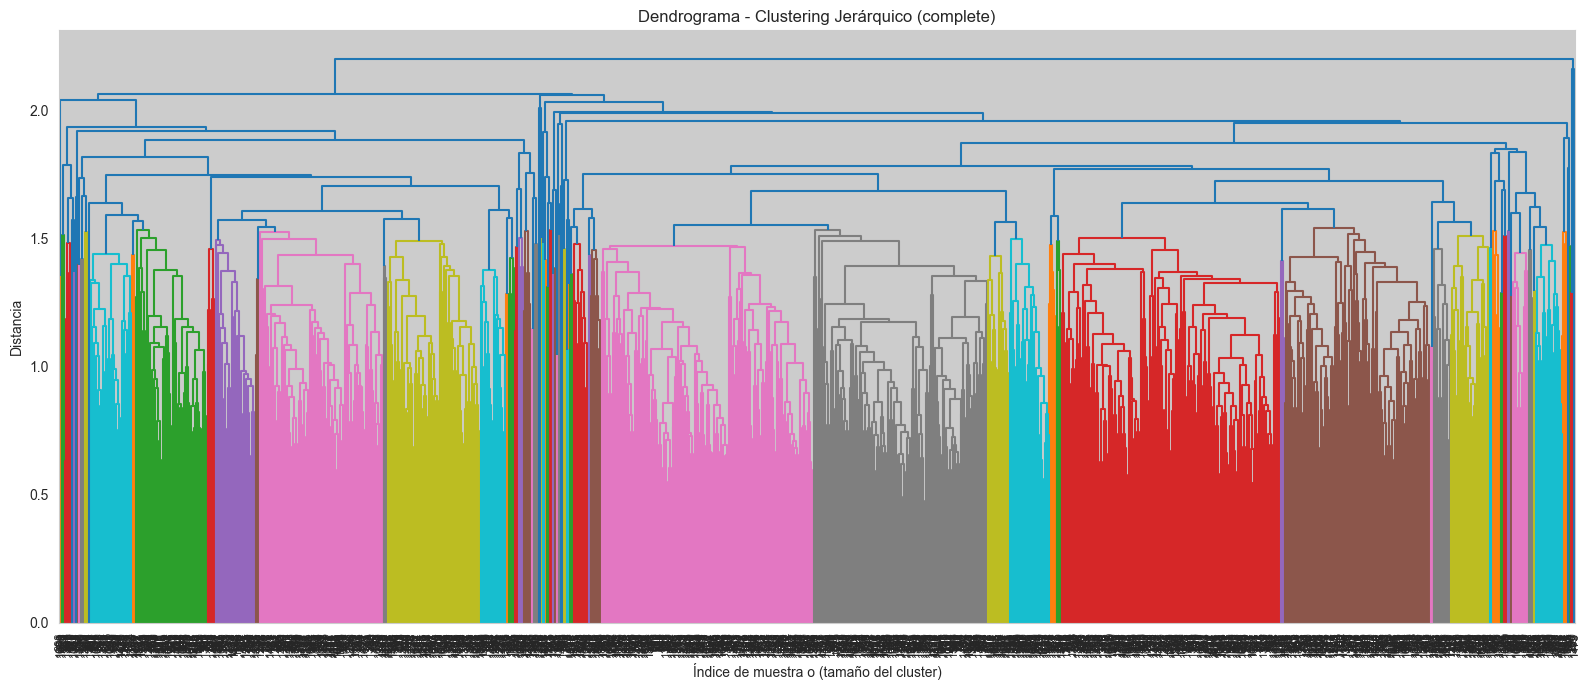

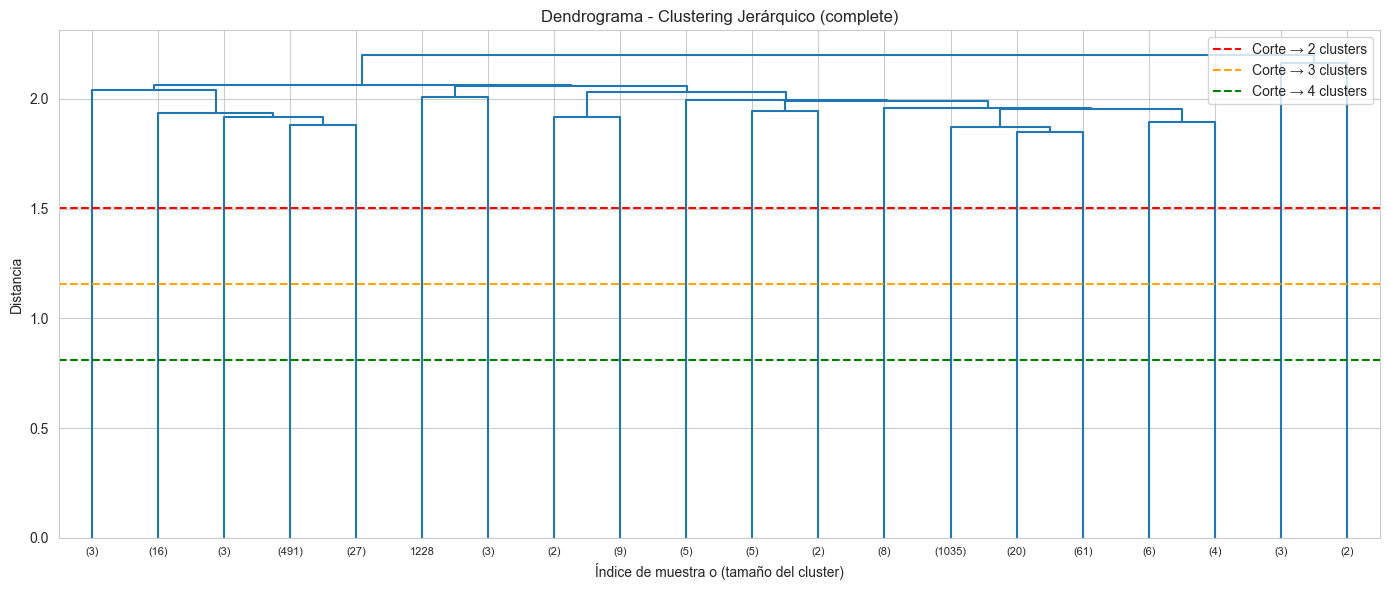

In [6]:
print('\n--- DENDROGRAMA - W-HIERARCHICAL ---\n')

fig1 = whierarchical.plot_dendrogram(
    figsize=(16, 7),
    truncate_mode=None,
    save_path='../../figures/dendrograma_ponderado_completo.png'
)
fig1.show()

fig2 = whierarchical.plot_dendrogram(
    figsize=(14, 6),
    truncate_mode='lastp',
    p=20,
    save_path='../../figures/dendrograma_ponderado_truncado.png'
)

ax = fig2.gca()
colores = ['red', 'orange', 'green']
alturas = [0.65, 0.50, 0.35]

for altura, color, n in zip(alturas, colores, [2, 3, 4]):
    ax.axhline(
        y=altura * ax.get_ylim()[1],
        color=color,
        linestyle='--',
        linewidth=1.5,
        label=f'Corte → {n} clusters'
    )

ax.legend(loc='upper right')
fig2.show()

print('\nInterpretación:')
print(f'  Linkage usado: {whierarchical.linkage}')
print(f'  n_clusters actual: {whierarchical.n_clusters_}')
print(f'  Silhouette: {metrics_whc["silhouette"]:.4f}')
print('\n  Las líneas de corte muestran dónde cortar el dendrograma')
print('  para obtener 2, 3 o 4 clusters.')
print('  Los saltos grandes en altura = clusters naturales en los datos.')

### W-DBSCAN

In [7]:
print('\n--- PCA PARA W-DBSCAN ---\n')

# Aplicar pesos antes de PCA para que la reducción respete la ponderación
weights_arr = wm.get_weights_array(feature_order=df.columns.tolist())
df_weighted = df * weights_arr

pca = PCA(n_components=0.90, random_state=42)
df_pca_array = pca.fit_transform(df_weighted)

df_pca = pd.DataFrame(
    df_pca_array,
    columns=[f'PCA_{i+1}' for i in range(df_pca_array.shape[1])]
)

print(f'Dimensiones originales: {df.shape[1]}')
print(f'Dimensiones PCA (sobre espacio ponderado): {df_pca.shape[1]}')
print(f'Varianza explicada: {pca.explained_variance_ratio_.sum():.4f}')
print('\nNota: PCA aplicado sobre el espacio ponderado para que la reducción')
print('  preserve la importancia diferencial de las características.')


--- PCA PARA W-DBSCAN ---

Dimensiones originales: 28
Dimensiones PCA (sobre espacio ponderado): 17
Varianza explicada: 0.9051

Nota: PCA aplicado sobre el espacio ponderado para que la reducción
  preserve la importancia diferencial de las características.



--- BÚSQUEDA DE CONFIGURACIÓN - W-DBSCAN ---

Pesos cargados desde C:\Users\pabli\AppData\Local\Temp\tmpxeux8u09.json, total de características: 17.
ANÁLISIS DE PARÁMETROS DBSCAN
Dataset: 1706 muestras × 17 features

Regla empírica para min_samples (>= n_features = 17):
  k candidatos a explorar: [8, 17, 25, 34]

Codos detectados (eps candidatos por valor de k):
  k (min_samples)      eps en codo     interpretación
  -------------------------------------------------------
  k=8                  eps≈0.8655        conservador (más clusters, menos ruido)
  k=17                 eps≈0.9467        recomendado
  k=25                 eps≈0.9895        recomendado
  k=34                 eps≈1.0645        agresivo (menos clusters, más ruido)

✓ Gráfico guardado en: C:\electocluster\results/clustering/kdistance_plot_ponderado.png


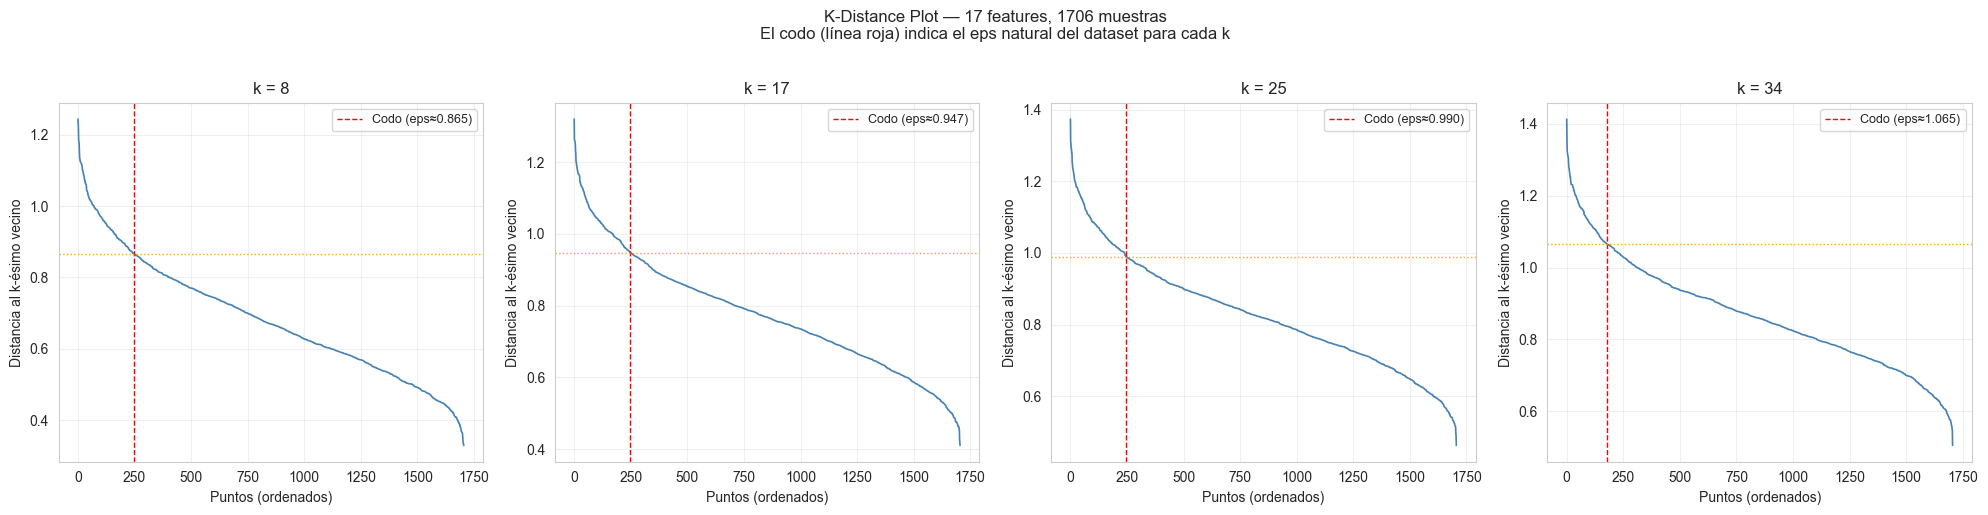


ESPACIO DE BÚSQUEDA RECOMENDADO
  eps:          [0.606, 0.736, 0.866, 0.996, 1.126, 1.256, 1.386]
  min_samples:  [8, 17, 25, 34]

  Combinaciones totales: 28

Eps candidatos por valor de k:
  k=8      eps_codo=0.8655     rango=[0.3293, 1.2434]
  k=17     eps_codo=0.9467     rango=[0.4103, 1.3201]
  k=25     eps_codo=0.9895     rango=[0.463, 1.3733]
  k=34     eps_codo=1.0645     rango=[0.5052, 1.4131]

Espacio de búsqueda derivado:
  eps:         [0.606, 0.736, 0.866, 0.996, 1.126, 1.256, 1.386]
  min_samples: [8, 17, 25, 34]
  Combinaciones totales: 28


In [8]:
print('\n--- BÚSQUEDA DE CONFIGURACIÓN - W-DBSCAN ---\n')

# Usar el mismo analyze_dbscan_params sobre el espacio PCA ponderado
# W-DBSCAN recibe df_pca con columnas PCA_1..N y un WeightManager con pesos uniformes
# (el espacio ya está ponderado, así que los pesos internos son iguales)
import json, tempfile
pca_weights = {col: 1.0 for col in df_pca.columns}
tmp = tempfile.NamedTemporaryFile(suffix='.json', delete=False, mode='w', encoding='utf-8')
json.dump({'features': pca_weights, 'metadata': {}}, tmp)
tmp.close()
wm_pca = WeightManager(weight_path_=tmp.name)

analisis = analyze_dbscan_params(
    df_pca,
    output_path=f'{RESULTS_PATH}/clustering/kdistance_plot_ponderado.png'
)
plt.show()

print('\nEps candidatos por valor de k:')
for k, datos in analisis['analisis_por_k'].items():
    print(f'  k={k:<6} eps_codo={datos["eps_codo"]:<10} '
          f'rango=[{datos["distancia_min"]}, {datos["distancia_max"]}]')

espacio = analisis['espacio_sugerido']
print(f'\nEspacio de búsqueda derivado:')
print(f'  eps:         {espacio["eps"]["valores"]}')
print(f'  min_samples: {espacio["min_samples"]["valores"]}')
print(f'  Combinaciones totales: '
      f'{len(espacio["eps"]["valores"]) * len(espacio["min_samples"]["valores"])}')

configs = build_dbscan_configs(analisis)

In [9]:
print('\n--- W-DBSCAN ---\n')

mejor_config = None
mejor_sil = -1

for cfg in configs:
    wdb_temp = WDBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'], weight_manager=wm_pca)
    wdb_temp.fit(df_pca)
    if wdb_temp.n_clusters_ >= 2:
        mask = wdb_temp.labels_ != -1
        sil = calculate_metrics(df_pca[mask], wdb_temp.labels_[mask])['silhouette']
        print(f'  eps={cfg["eps"]}, min_samples={cfg["min_samples"]}: '
              f'{wdb_temp.n_clusters_} clusters, '
              f'ruido={wdb_temp.n_noise_points_} ({wdb_temp.n_noise_points_/len(df_pca)*100:.1f}%), '
              f'Sil={sil:.4f}')
        if sil > mejor_sil:
            mejor_sil = sil
            mejor_config = cfg
            wdbscan = wdb_temp
    else:
        print(f'  eps={cfg["eps"]}, min_samples={cfg["min_samples"]}: sin clusters')

if mejor_config:
    print(f'\n✓ Mejor configuración: {mejor_config} → Sil={mejor_sil:.4f}')
else:
    print('⚠ Ninguna configuración generó clusters válidos')

print(f'\nConfiguración final: eps={wdbscan.eps}, min_samples={wdbscan.min_samples}')
print(f'Clusters identificados: {wdbscan.n_clusters_}')
print(f'Puntos de ruido: {wdbscan.n_noise_points_} ({wdbscan.n_noise_points_/len(df_pca)*100:.1f}%)')
print(f'\nTamaños:')
print(wdbscan.get_cluster_sizes())

if wdbscan.n_clusters_ >= 2:
    mask = wdbscan.labels_ != -1
    df_clean = df_pca[mask]
    labels_clean = wdbscan.labels_[mask]
    print('\nMétricas (sin ruido):')
    metrics_wdb = calculate_metrics(df_clean, labels_clean)
else:
    print('\n⚠ W-DBSCAN no generó clusters válidos con ninguna configuración')
    metrics_wdb = None

print('='*70)


--- W-DBSCAN ---

Entrenando DBSCAN (eps=0.606, min_samples=8)...
✓ WDBSCAN entrenado:
  Clusters identificados: 21
  Puntos de ruido: 634 (37.16%)
  Puntos core: 678
Calculando métricas de validación...
  Muestras: 1072
  Clusters: 21
  ✓ Silhouette Score: 0.2063
  ✓ Davies-Bouldin Index: 1.6024
  ✓ Calinski-Harabasz Index: 91.2002
  eps=0.606, min_samples=8: 21 clusters, ruido=634 (37.2%), Sil=0.2063
Entrenando DBSCAN (eps=0.606, min_samples=17)...
✓ WDBSCAN entrenado:
  Clusters identificados: 11
  Puntos de ruido: 982 (57.56%)
  Puntos core: 281
Calculando métricas de validación...
  Muestras: 724
  Clusters: 11
  ✓ Silhouette Score: 0.2217
  ✓ Davies-Bouldin Index: 1.6177
  ✓ Calinski-Harabasz Index: 109.0000
  eps=0.606, min_samples=17: 11 clusters, ruido=982 (57.6%), Sil=0.2217
Entrenando DBSCAN (eps=0.606, min_samples=25)...
✓ WDBSCAN entrenado:
  Clusters identificados: 7
  Puntos de ruido: 1204 (70.57%)
  Puntos core: 122
Calculando métricas de validación...
  Muestras: 502


### COMPARACIÓN DE ALGORITMOS PONDERADOS

In [10]:
print('\n--- COMPARACIÓN DE ALGORITMOS PONDERADOS Y MÉTRICAS ---\n')

comparison_data = {
    'Algoritmo': ['W-KMedoids', 'W-Hierarchical', 'W-DBSCAN'],
    'Clusters': [wkmedoids.n_clusters_, whierarchical.n_clusters_, wdbscan.n_clusters_],
    'Silhouette': [
        metrics_wkm['silhouette'],
        metrics_whc['silhouette'],
        metrics_wdb['silhouette'] if metrics_wdb else np.nan
    ],
    'Davies-Bouldin': [
        metrics_wkm['davies_bouldin'],
        metrics_whc['davies_bouldin'],
        metrics_wdb['davies_bouldin'] if metrics_wdb else np.nan
    ],
    'Calinski-Harabasz': [
        metrics_wkm['calinski_harabasz'],
        metrics_whc['calinski_harabasz'],
        metrics_wdb['calinski_harabasz'] if metrics_wdb else np.nan
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print('\n' + '='*70)
print('✓ CLUSTERING PONDERADO COMPLETADO')
print('='*70)


--- COMPARACIÓN DE ALGORITMOS PONDERADOS Y MÉTRICAS ---

     Algoritmo  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
    W-KMedoids        13    0.106235        2.452128          94.959353
W-Hierarchical         2    0.140907        2.307410         254.693043
      W-DBSCAN         4    0.295764        1.359318         120.306149

✓ CLUSTERING PONDERADO COMPLETADO


### PERFIL SOCIOPOLÍTICO DE CLUSTERS


--- PERFIL SOCIOPOLÍTICO DE CLUSTERS ---


===== W-KMedoids =====

Media de variables por cluster:
          edre  q10inc   etid  boletidnew  boletidnewb  estratopri     ur  \
cluster                                                                     
0        0.656   0.177  0.289       0.991        0.222       0.314  1.000   
1        0.468   0.142  0.293       0.843        0.243       0.461  0.009   
2        0.664   0.175  0.271       0.991        0.390       0.498  1.000   
3        0.455   0.162  0.243       0.888        0.206       0.485  0.056   
4        0.804   0.310  0.198       0.000        0.000       0.438  1.000   
5        0.570   0.199  0.267       0.748        0.210       0.488  0.000   
6        0.736   0.287  0.210       0.021        0.003       0.466  1.000   
7        0.722   0.234  0.245       0.047        0.007       0.408  1.000   
8        0.664   0.231  0.226       0.017        0.004       0.390  0.983   
9        0.639   0.213  0.283       0.984        0.27

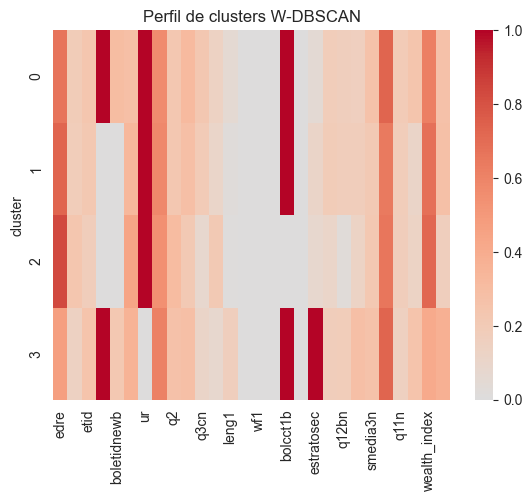

In [11]:
print('\n--- PERFIL SOCIOPOLÍTICO DE CLUSTERS ---\n')

def analizar_clusters(df_original, labels, nombre_algoritmo):
    df_analysis = df_original.copy()
    df_analysis['cluster'] = labels
    # Eliminar ruido si es DBSCAN
    df_analysis = df_analysis[df_analysis['cluster'] != -1]
    
    print(f'\n===== {nombre_algoritmo} =====')
    resumen = df_analysis.groupby('cluster').mean()
    print('\nMedia de variables por cluster:')
    print(resumen.round(3))
    print('\nTamaño de clusters:')
    print(df_analysis['cluster'].value_counts().sort_index())
    return resumen

perfil_wkm = analizar_clusters(df, wkmedoids.labels_, 'W-KMedoids')
perfil_whc = analizar_clusters(df, whierarchical.labels_, 'W-Hierarchical')
perfil_wdb = analizar_clusters(df, wdbscan.labels_, 'W-DBSCAN')

sns.heatmap(perfil_wdb, cmap='coolwarm', center=0)
plt.title('Perfil de clusters W-DBSCAN')
plt.show()

### VISUALIZACIÓN DE CLUSTERS


--- VISUALIZACIÓN DE CLUSTERS PONDERADOS ---

✓ Varianza explicada: 28.32%
  PC1: 17.86%
  PC2: 10.47%


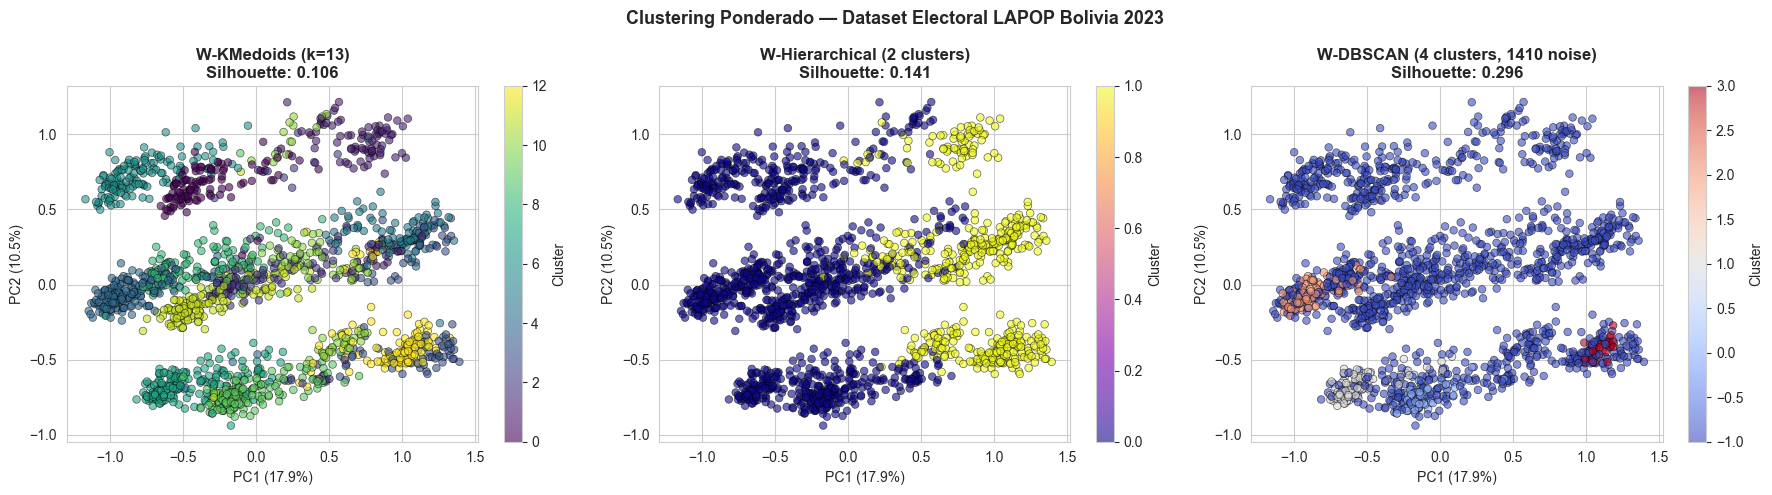


✓ Visualización guardada en: figures/comparacion_clusters_ponderados_2d.png


In [12]:
print('\n--- VISUALIZACIÓN DE CLUSTERS PONDERADOS ---\n')

# PCA 2D sobre espacio original para visualización comparable
pca_vis = PCA(n_components=2, random_state=42)
df_2d = pca_vis.fit_transform(df)

print(f'✓ Varianza explicada: {pca_vis.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  PC1: {pca_vis.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2: {pca_vis.explained_variance_ratio_[1]*100:.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Clustering Ponderado — Dataset Electoral LAPOP Bolivia 2023',
             fontweight='bold', fontsize=13)

# W-KMedoids
scatter1 = axes[0].scatter(
    df_2d[:, 0], df_2d[:, 1],
    c=wkmedoids.labels_, cmap='viridis',
    alpha=0.6, s=30, edgecolors='black', linewidth=0.5
)
axes[0].set_title(f'W-KMedoids (k={wkmedoids.n_clusters_})\nSilhouette: {metrics_wkm["silhouette"]:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# W-Hierarchical
scatter2 = axes[1].scatter(
    df_2d[:, 0], df_2d[:, 1],
    c=whierarchical.labels_, cmap='plasma',
    alpha=0.6, s=30, edgecolors='black', linewidth=0.5
)
axes[1].set_title(f'W-Hierarchical ({whierarchical.n_clusters_} clusters)\nSilhouette: {metrics_whc["silhouette"]:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# W-DBSCAN
if wdbscan.n_clusters_ >= 2:
    scatter3 = axes[2].scatter(
        df_2d[:, 0], df_2d[:, 1],
        c=wdbscan.labels_, cmap='coolwarm',
        alpha=0.6, s=30, edgecolors='black', linewidth=0.5
    )
    title3 = (f'W-DBSCAN ({wdbscan.n_clusters_} clusters, '
              f'{wdbscan.n_noise_points_} noise)\n'
              f'Silhouette: {metrics_wdb["silhouette"]:.3f}')
    plt.colorbar(scatter3, ax=axes[2], label='Cluster')
else:
    axes[2].scatter(df_2d[:, 0], df_2d[:, 1],
                    c='gray', alpha=0.3, s=30,
                    edgecolors='black', linewidth=0.5)
    title3 = 'W-DBSCAN (Sin clusters)\nTodos los puntos = ruido'

axes[2].set_title(title3, fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.savefig('../../figures/comparacion_clusters_ponderados_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Visualización guardada en: figures/comparacion_clusters_ponderados_2d.png')
print('='*70)